# Univariate and Bivariate Analysis of Application (Documentation) Data
- table - application_train.csv 
---

Document provided by client:
- `FLAG_DOCUMENT_2` - Did client provide document 2
- `FLAG_DOCUMENT_3` - Did client provide document 3
- `FLAG_DOCUMENT_4` - Did client provide document 4
- `FLAG_DOCUMENT_5` - Did client provide document 5
- `FLAG_DOCUMENT_6`  - Did client provide document 6
- `FLAG_DOCUMENT_7`  - Did client provide document 7
- `FLAG_DOCUMENT_8` - Did client provide document 8
- `FLAG_DOCUMENT_9` - Did client provide document 9
- `FLAG_DOCUMENT_10` - Did client provide document 10
- `FLAG_DOCUMENT_11` - Did client provide document 11
- `FLAG_DOCUMENT_12` - Did client provide document 12
- `FLAG_DOCUMENT_13` - Did client provide document 13
- `FLAG_DOCUMENT_14` - Did client provide document 14
- `FLAG_DOCUMENT_15` - Did client provide document 15
- `FLAG_DOCUMENT_16` - Did client provide document 16
- `FLAG_DOCUMENT_17` - Did client provide document 17
- `FLAG_DOCUMENT_18` - Did client provide document 18
- `FLAG_DOCUMENT_19` - Did client provide document 19
- `FLAG_DOCUMENT_20` - Did client provide document 20
- `FLAG_DOCUMENT_21` - Did client provide document 21

## 0. Import Libraries and Data

In [31]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import plot_binary_distribution, plot_binary_vs_binary
from preprocess_module import filter_binary_features

In [32]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
document_provided_cols = [
    'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17',
    'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
    'TARGET'
]
app_df = app_df[document_provided_cols]
document_provided_cols.remove('TARGET')
print(document_provided_cols)
print(f"Shape of app_df with document columns: {app_df.shape}")
app_df.head(10)

['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']
Shape of app_df with document columns: (307511, 21)


,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,...,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,TARGET
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
7,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 1. Decide which variables are not homogeneous.

In [33]:
cols_to_drop, document_summary = filter_binary_features(
    df=app_df, 
    binary_cols=document_provided_cols,
    minimum_share=0.05,
    return_homogeneous_cols=True
)
print(cols_to_drop, "\n")
document_summary

['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'] 



,feature,n_unique_observed,minority_category,minority_share,minimum_share,keep
0,FLAG_DOCUMENT_12,2,1,0.000007,0.05,False
1,FLAG_DOCUMENT_10,2,1,0.000023,0.05,False
2,FLAG_DOCUMENT_2,2,1,0.000042,0.05,False
3,FLAG_DOCUMENT_4,2,1,0.000081,0.05,False
4,FLAG_DOCUMENT_7,2,1,0.000192,0.05,False
5,FLAG_DOCUMENT_17,2,1,0.000267,0.05,False
6,FLAG_DOCUMENT_21,2,1,0.000335,0.05,False
7,FLAG_DOCUMENT_20,2,1,0.000507,0.05,False
8,FLAG_DOCUMENT_19,2,1,0.000595,0.05,False
9,FLAG_DOCUMENT_15,2,1,0.001210,0.05,False


In [34]:
app_df = app_df.drop(columns=cols_to_drop)
app_df.head()

,FLAG_DOCUMENT_3,FLAG_DOCUMENT_6,FLAG_DOCUMENT_8,TARGET
0,1,0,0,1
1,1,0,0,0
2,0,0,0,0
3,1,0,0,0
4,0,0,1,0


## 2. Show the distributions of variables that passed the filtering process.

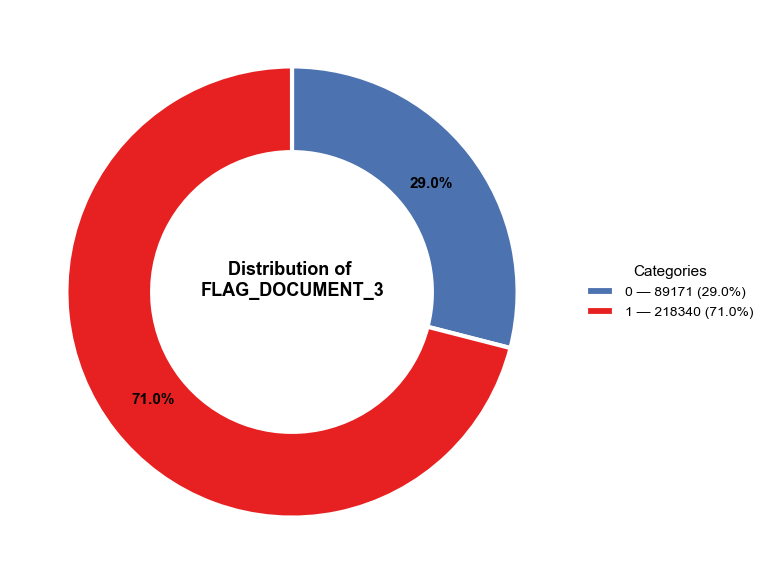

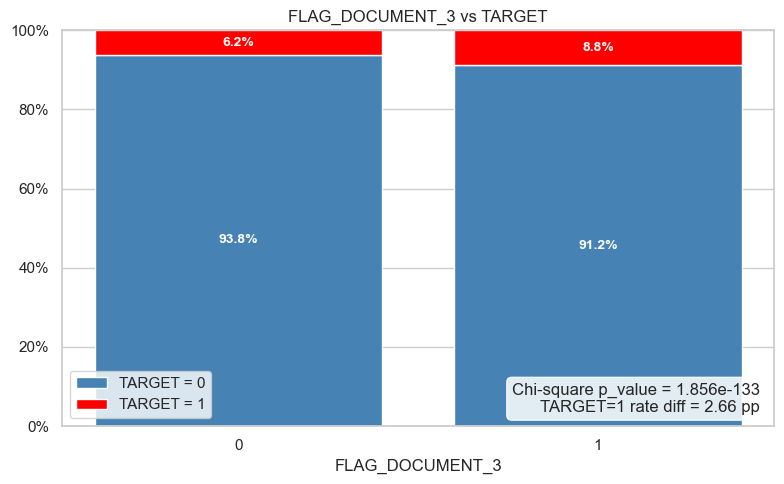

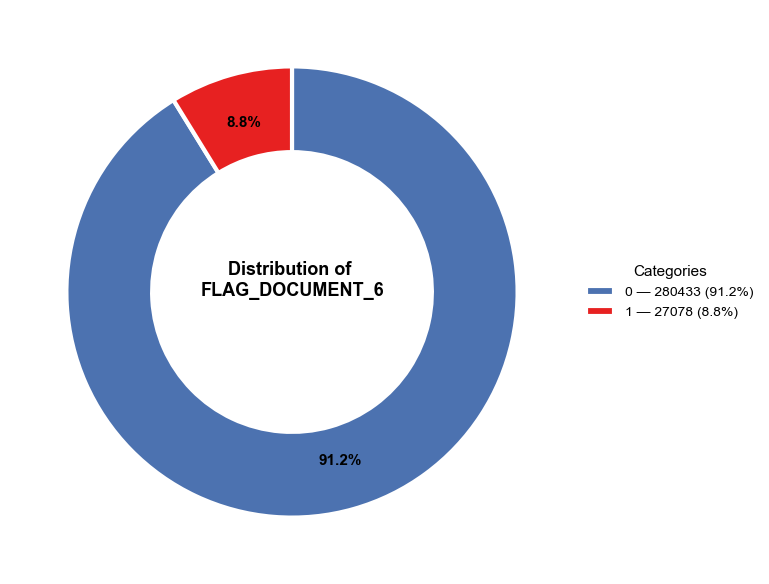

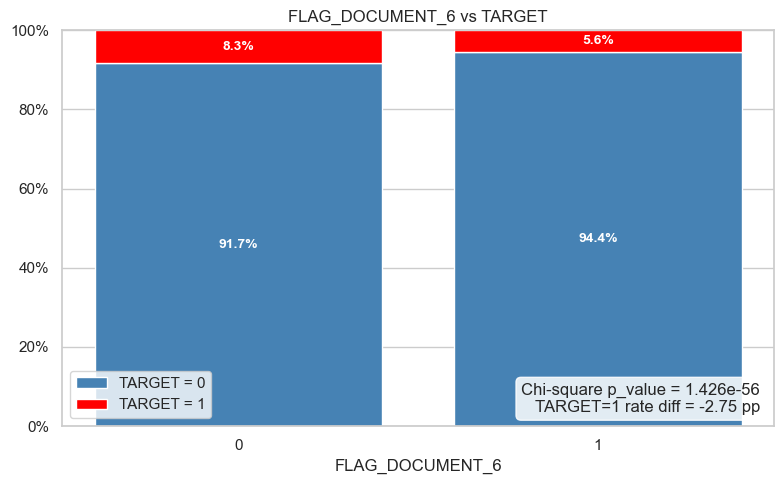

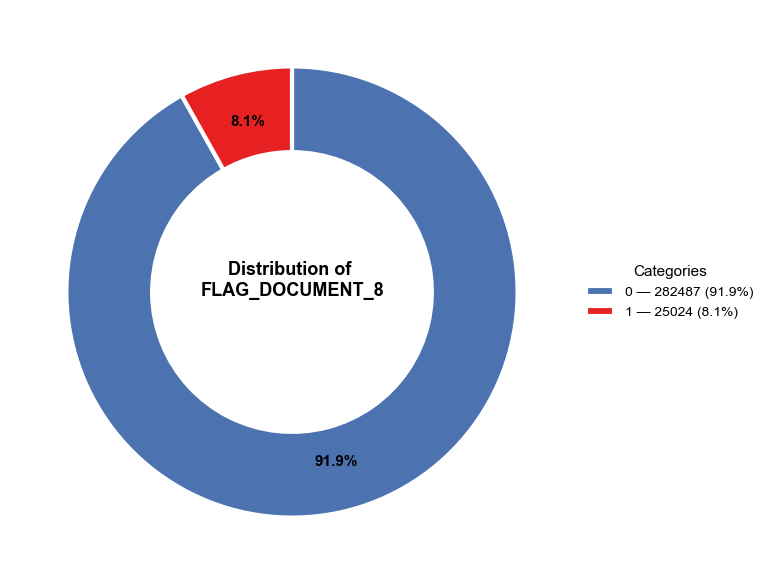

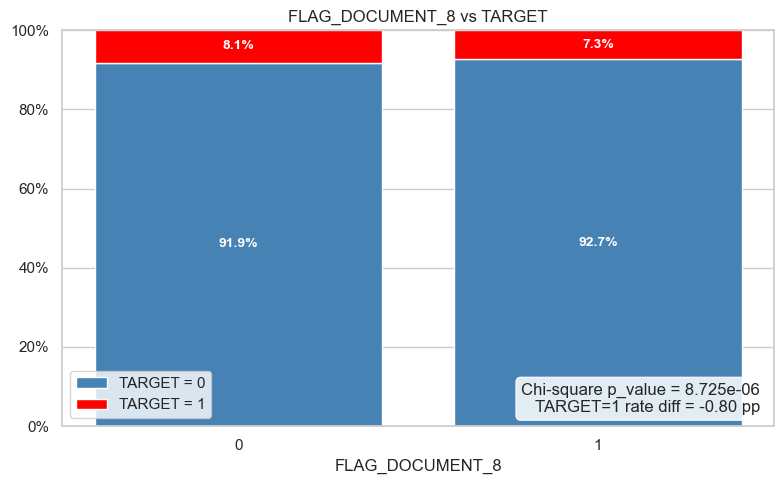

In [35]:
for col in app_df.drop(columns='TARGET').columns:
    plot_binary_distribution(df=app_df, binary_var=col)
    plot_binary_vs_binary(df=app_df, binary_var=col, target_var='TARGET')

The variables will be used in modeling, they hold little information, though.

## 21. Application process summary
Variables that should be used as predictors
- `FLAG_DOCUMENT_3`
- `FLAG_DOCUMENT_6`
- `FLAG_DOCUMENT_8`